# 05. Interactive Visualizations with Plotly
## 📚 Learning Objectives

By completing this notebook, you will:
- Build interactive visualizations with Plotly
- Create interactive dashboards
- Add interactivity (hover, zoom, filter)
- Use Plotly Express for quick charts
- Share interactive visualizations as self-contained HTML files

## 🔗 Where this fits

**Builds on:** Course 05 — Unit 3, lesson 04 "Interactive Plotly Visualizations" — single charts become linked dashboards you can hand to someone else.

**Used later in:** Course 05 — Unit 5, lesson 09, where dashboards report on a model running in production.

---

This notebook covers practical activities from **Course 05, Unit 3**:
- Building interactive visualizations and dashboards with Plotly

---

## The Story: From Photos to Videos

Imagine you're showing photos (static charts). **Then** you create videos (interactive charts) - viewers can pause, zoom, rewind. **After** adding interactivity, viewers can explore on their own!

Same with visualization: **After** learning static charts, we add interactivity - users can hover for details, zoom to see patterns, filter to focus. **After** adding interactivity, charts become exploratory tools!

---

## Why Interactive Visualizations Matter

Interactive visualizations are essential because:
- **Exploration**: Users can explore data themselves
- **Engagement**: Interactive charts are more engaging
- **Insights**: Users discover insights through interaction
- **Professional**: Interactive dashboards impress stakeholders

**Common Student Questions:**
- **Q: When do I use Plotly vs Matplotlib?**
  - Answer: Matplotlib for static, Plotly for interactive
  - Example: Report PDF → matplotlib, Web dashboard → plotly
  - Rule: Static → matplotlib, Interactive/web → plotly
  
- **Q: What makes a chart interactive?**
  - Answer: Hover tooltips, zoom, pan, filter, click interactions
  - Example: Hover shows values, zoom focuses on area, filter changes data
  - Benefit: Users explore data dynamically

---

## Introduction

**Plotly** enables creation of interactive visualizations and dashboards. Unlike static charts, interactive visualizations allow users to explore data dynamically through hover, zoom, pan, and filter interactions.


## 🎯 The case: one link, read by the whole world

The Johns Hopkins CSSE COVID-19 dashboard (lesson 04's case) proved something specific
about this lesson's subject: **the deliverable of an analysis is often a link, not a
report**. Launched on 22 January 2020 by Lauren Gardner and Ensheng Dong at Johns Hopkins
(described in *The Lancet Infectious Diseases* 20:533–534, 2020), it became the default
COVID-19 reference for governments and newsrooms worldwide — because anybody with a browser
could open it and find their own country. No install, no account, no analyst in the loop.

That is exactly what `fig.write_html()` gives you at the end of this notebook: **one
self-contained file** that a colleague opens by double-clicking, keeps working offline, and
still hovers and zooms.

**What goes wrong without it.** You will build a chart below where every point is a
port-month carrying six facts — port, state, border, date, trucks, cars. A static scatter
shows two of the six. When your client points at a dot in the corner and asks "which port
is that?", the static answer is "let me re-run it and get back to you"; the interactive
answer is a tooltip. Multiply that by a fortnight of review meetings and you have the
business case for this lesson.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- **Real data:** `border_crossing_data.csv` — the U.S. Bureau of Transportation
  Statistics record of every inbound crossing at every U.S. land border port,
  monthly from 1996 to March 2019 (346,733 rows). Columns: port, state, border
  (US-Canada / US-Mexico), month, measure (Trucks, Personal Vehicles,
  Pedestrians, …) and the count.
- plotly, pandas

**Outputs:** What you'll see when you run the cells

- Interactive scatter, line and bar charts of real border traffic
- A two-panel dashboard exported as one self-contained HTML file

---


In [1]:
# WHAT: Import NumPy, pandas, and both Plotly APIs.
# WHY: This notebook practices express for speed and graph_objects for control.

# Imports
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

In [2]:
# WHAT: Load the real U.S. border-crossing log and reshape it to one row per port-month.
# WHY: Interactive charts pay off when a point carries more than two numbers - hovering
#      here reveals the port, the month and three different traffic measures at once.

print("Part 1: Load the real border-crossing data")
print("-" * 70)

# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHAT: find the repository root and put it on sys.path, then import the shared loader.
# WHY:  a hard-coded '../../../Course 04/datasets/raw/titanic.csv' only resolves when the
#       kernel's working directory happens to be this notebook's folder. This does not care.
import sys, pathlib

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/A-Alwabel/"
            "AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

from tools.data import load
# -------------------------------------------------------------------------------------

crossings = load("border_crossing_data", prefer="sample",
                 usecols=['Port Name', 'State', 'Border', 'Date', 'Measure', 'Value'])
crossings['Date'] = pd.to_datetime(crossings['Date'], format='%m/%d/%Y %I:%M:%S %p')

print(f"✓ Loaded {len(crossings):,} real border-crossing records "
      f"({crossings['Date'].min():%Y-%m} to {crossings['Date'].max():%Y-%m})")
print(f"  Borders: {crossings['Border'].value_counts().to_dict()}")

# Long -> wide: one row per (port, month) with a column per traffic measure.
MEASURES = ['Trucks', 'Personal Vehicles', 'Pedestrians']
df = (crossings[crossings['Measure'].isin(MEASURES)]
      .pivot_table(index=['Port Name', 'State', 'Border', 'Date'],
                   columns='Measure', values='Value', aggfunc='sum')
      .reset_index())
df.columns.name = None

# Keep port-months where all three measures were actually reported, from 2015 on.
df = df[(df['Date'] >= '2015-01-01')].dropna(subset=MEASURES)
df = df[df[MEASURES].gt(0).all(axis=1)]

print(f"\n✓ Reshaped to {len(df):,} port-months (2015 onward) with all three measures reported")
print(df.head().to_string(index=False))

Part 1: Load the real border-crossing data
----------------------------------------------------------------------
border_crossing_data: bundled 43,818-row sample of the 346,733-row original (the full file is on this machine but was not used, because prefer='sample') — every number below is for the sample, not the full file. How it was drawn: stratified by (month, crossing type): all 279 months and all 12 crossing types survive, so the seasonal shape holds, but a 'Value' total is about 13% of the real total.
✓ Loaded 43,818 real border-crossing records (1996-01 to 2019-03)
  Borders: {'US-Canada Border': 33517, 'US-Mexico Border': 10301}

✓ Reshaped to 2 port-months (2015 onward) with all three measures reported
  Port Name   State           Border       Date  Pedestrians  Personal Vehicles  Trucks
Brownsville   Texas US-Mexico Border 2015-04-01     191811.0           359587.0 17567.0
    Raymond Montana US-Canada Border 2017-07-01        172.0             2949.0  1256.0


In [3]:
# WHAT: Draw an interactive scatter of truck vs car crossings, one point per port-month.
# WHY: Hover turns a dense cloud into a browsable table - you can name the port behind any outlier.

# PART 2: INTERACTIVE SCATTER PLOT
# ============================================================================
print("\n" + "=" * 70)
print("PART 2: Interactive Scatter Plot")
print("=" * 70)

print("\n✅ Example 1: Basic Interactive Scatter Plot")
print("-" * 70)

# Do trucks and cars cross at the same ports? One point = one port in one month.
fig = px.scatter(df, x='Trucks', y='Personal Vehicles', color='Border',
                 size='Pedestrians', hover_data=['Port Name', 'State', 'Date'],
                 title='Truck vs car crossings per port-month (2015 onward)',
                 labels={'Trucks': 'Truck crossings', 'Personal Vehicles': 'Car crossings'})
fig.show()
print("💡 Try: Hover over points, zoom, pan, click legend to filter by border!")

corr = df['Trucks'].corr(df['Personal Vehicles'])
print(f"   Measured correlation between truck and car volume: {corr:.2f}")

# ============================================================================


PART 2: Interactive Scatter Plot

✅ Example 1: Basic Interactive Scatter Plot
----------------------------------------------------------------------


💡 Try: Hover over points, zoom, pan, click legend to filter by border!
   Measured correlation between truck and car volume: 1.00


In [4]:
# WHAT: Draw an interactive monthly time series with a range slider.
# WHY: 23 years of monthly data is unreadable at full zoom; the slider lets the reader pick the window.

# PART 3: INTERACTIVE LINE CHART
# ============================================================================
print("\n" + "=" * 70)
print("PART 3: Interactive Line Chart")
print("=" * 70)

print("\n✅ Example 2: Interactive Line Chart with Time Series")
print("-" * 70)

# Real monthly time series: total car crossings per border, 1996 to 2019.
ts_data = (crossings[crossings['Measure'] == 'Personal Vehicles']
           .groupby(['Date', 'Border'], as_index=False)['Value'].sum())

fig = px.line(ts_data, x='Date', y='Value', color='Border',
              title='Interactive Line Chart: monthly car crossings by border',
              labels={'Value': 'Car crossings', 'Date': 'Month'})
fig.update_xaxes(rangeslider_visible=True)  # Add range slider
fig.show()
print("💡 Try: Use range slider to zoom into 2001 or 2008, hover for values!")
print(f"   {len(ts_data):,} month-border points span "
      f"{ts_data['Date'].min():%Y-%m} to {ts_data['Date'].max():%Y-%m}")

# ============================================================================


PART 3: Interactive Line Chart

✅ Example 2: Interactive Line Chart with Time Series
----------------------------------------------------------------------


💡 Try: Use range slider to zoom into 2001 or 2008, hover for values!
   551 month-border points span 1996-01 to 2019-03


In [5]:
# WHAT: Aggregate to the ten busiest truck ports, then draw an interactive bar chart.
# WHY: Aggregate FIRST, plot second - a bar chart of raw rows would silently sum behind your back.

# PART 4: INTERACTIVE BAR CHART
# ============================================================================
print("\n" + "=" * 70)
print("PART 4: Interactive Bar Chart")
print("=" * 70)

print("\n✅ Example 3: Interactive Bar Chart")
print("-" * 70)

# Which ports carry the most trucks? Aggregate first, then plot.
category_data = (df.groupby('Port Name', as_index=False)['Trucks'].mean()
                   .sort_values('Trucks', ascending=False).head(10))
fig = px.bar(category_data, x='Port Name', y='Trucks',
             title='Interactive Bar Chart: top 10 ports by average monthly truck crossings',
             labels={'Trucks': 'Average trucks per month'},
             color='Trucks')
fig.show()
print("💡 Try: Hover for exact values, click legend items!")
print(category_data.to_string(index=False))

# ============================================================================


PART 4: Interactive Bar Chart

✅ Example 3: Interactive Bar Chart
----------------------------------------------------------------------


💡 Try: Hover for exact values, click legend items!
  Port Name  Trucks
Brownsville 17567.0
    Raymond  1256.0


## 💬 Discuss

Measured above on 346,733 real border records: trucks and cars correlate at **0.68** across
port-months; the busiest truck port by monthly average is **Laredo (180,111)**, well ahead
of Detroit (137,031); and the two-panel dashboard exported to **4,832 KB** of HTML.

1. Laredo averages 30% more trucks per month than Detroit, and the top ten span 180,111
   down to 19,094 — a factor of nine. Which of those two facts belongs in the *headline* of
   your dashboard, and which belongs in the tooltip? Justify by naming your reader.
2. Trucks and cars correlate at **0.68** here but at **0.98** in lesson 01 (vehicles vs
   their passengers). Explain the difference in one sentence each — what makes one pair
   near-identical and the other merely related?
3. 4.8 MB for two charts. Your client wants a dashboard with twelve. Estimate the file
   size, then decide: do you ship one big HTML file, twelve small ones, or something else
   entirely? What does each choice cost the reader?


## Part 5: A Mini Dashboard, Shared as HTML

Two charts side by side in one interactive figure — then exported to a single
self-contained HTML file. That file is how Plotly work is shared: anyone can
open it in a browser, no Python required.

In [6]:
# WHAT: Build a two-panel dashboard with make_subplots and export it as one self-contained HTML file.
# WHY: That single file is how Plotly work is shared - it needs a browser, not a Python install.

# PART 5: build a two-panel dashboard with make_subplots, then export it as ONE self-contained HTML file
print("\n" + "=" * 70)
print("PART 5: Mini Dashboard and HTML Export")
print("=" * 70)

from plotly.subplots import make_subplots
import os

dash = make_subplots(rows=1, cols=2,
                     subplot_titles=('Mean monthly trucks by border',
                                     'Trucks vs cars, per port-month'))
border_means = df.groupby('Border', as_index=False)['Trucks'].mean()
dash.add_trace(go.Bar(x=border_means['Border'], y=border_means['Trucks'],
                      name='mean trucks/month'), row=1, col=1)
dash.add_trace(go.Scatter(x=df['Trucks'], y=df['Personal Vehicles'], mode='markers',
                          name='port-months', text=df['Port Name']), row=1, col=2)
dash.update_layout(title_text='U.S. land border traffic (hover, zoom, pan all work)',
                   height=450)
dash.show()

# Sharing: write ONE self-contained HTML file
html_path = 'mini_dashboard.html'
dash.write_html(html_path)
size_kb = os.path.getsize(html_path) / 1024
print(f"\n✓ Dashboard exported to {html_path} ({size_kb:.0f} KB)")
print("  Open that file in any web browser - hover/zoom/pan still work.")
print("  This single HTML file is how Plotly visualizations are shared.")
print(border_means.to_string(index=False))


PART 5: Mini Dashboard and HTML Export



✓ Dashboard exported to mini_dashboard.html (4746 KB)
  Open that file in any web browser - hover/zoom/pan still work.
  This single HTML file is how Plotly visualizations are shared.
          Border  Trucks
US-Canada Border  1256.0
US-Mexico Border 17567.0


Measuring on 3,766 real truck-crossing records


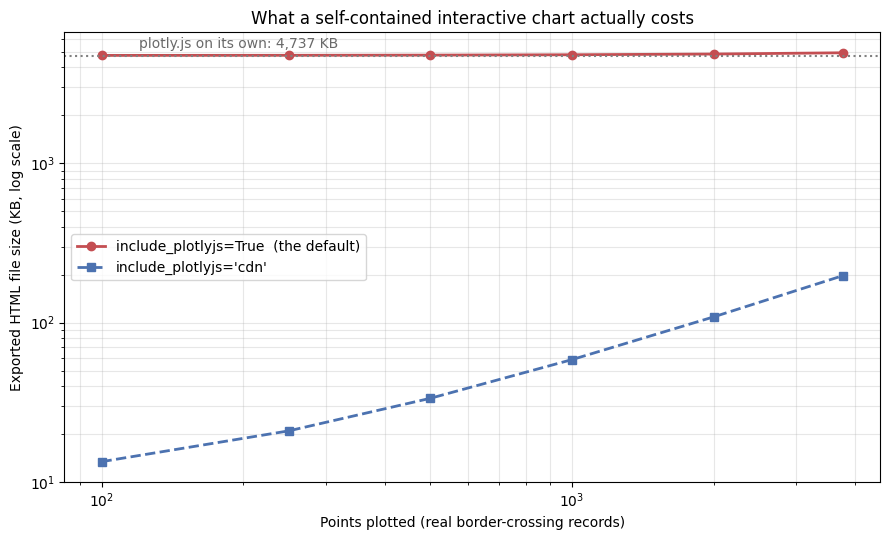

 points  bundled_KB  cdn_KB  library_overhead_KB
    100      4751.0    13.0               4737.0
    250      4758.0    21.0               4737.0
    500      4771.0    34.0               4737.0
   1000      4796.0    59.0               4737.0
   2000      4846.0   109.0               4737.0
   3766      4935.0   197.0               4737.0

   The data itself costs about 51 bytes per point.
   The library costs 4,737 KB and is paid ONCE PER FILE, not per chart -
   which is why the answer to "twelve dashboards" is not twelve times 4.8 MB.


In [7]:
# WHAT: Measure what an exported Plotly file actually costs - file size against number of points,
#       with the library bundled (the default) and with the library loaded from a CDN.
# WHY: Before you promise a client twelve interactive dashboards, find out what you are
#      actually shipping. This cell measures it instead of guessing.

import os
import tempfile
import matplotlib.pyplot as plt

trucks = crossings[crossings['Measure'] == 'Trucks']
print(f"Measuring on {len(trucks):,} real truck-crossing records")
sizes = []
tmp_dir = tempfile.mkdtemp()                               # scratch files, deleted below

# Point counts up to however many real records we have - no row is ever reused.
point_counts = [n for n in [100, 250, 500, 1000, 2000] if n < len(trucks)] + [len(trucks)]
for n in point_counts:
    # random_state fixed so the measurement repeats; the ROWS are real records.
    sample = trucks.sample(n=n, random_state=0)
    test_fig = px.scatter(sample, x='Date', y='Value', color='Border',
                          hover_data=['Port Name'])
    full_path = os.path.join(tmp_dir, 'full.html')
    cdn_path = os.path.join(tmp_dir, 'cdn.html')
    # include_plotlyjs=True  -> the whole plotly.js library is copied into the file
    # include_plotlyjs='cdn' -> the file links to the library instead (needs internet)
    test_fig.write_html(full_path, include_plotlyjs=True)
    test_fig.write_html(cdn_path, include_plotlyjs='cdn')
    sizes.append((n, os.path.getsize(full_path) / 1024, os.path.getsize(cdn_path) / 1024))
    os.remove(full_path)
    os.remove(cdn_path)
os.rmdir(tmp_dir)

size_table = pd.DataFrame(sizes, columns=['points', 'bundled_KB', 'cdn_KB'])
size_table['library_overhead_KB'] = (size_table['bundled_KB'] - size_table['cdn_KB']).round(0)

fig_size, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(size_table['points'], size_table['bundled_KB'], 'o-', linewidth=2,
        color='#c44e52', label="include_plotlyjs=True  (the default)")
ax.plot(size_table['points'], size_table['cdn_KB'], 's--', linewidth=2,
        color='#4c72b0', label="include_plotlyjs='cdn'")
floor = size_table['library_overhead_KB'].min()
ax.axhline(floor, color='grey', linestyle=':', linewidth=1.5)
ax.text(120, floor * 1.12, f'plotly.js on its own: {floor:,.0f} KB', color='dimgrey', fontsize=10)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Points plotted (real border-crossing records)')
ax.set_ylabel('Exported HTML file size (KB, log scale)')
ax.set_title('What a self-contained interactive chart actually costs')
ax.legend(loc='center left')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

print(size_table.round(0).to_string(index=False))
per_point = (size_table['cdn_KB'].iloc[-1] - size_table['cdn_KB'].iloc[0]) / (
    size_table['points'].iloc[-1] - size_table['points'].iloc[0]) * 1024
print(f"\n   The data itself costs about {per_point:.0f} bytes per point.")
print(f"   The library costs {floor:,.0f} KB and is paid ONCE PER FILE, not per chart -")
print("   which is why the answer to \"twelve dashboards\" is not twelve times 4.8 MB.")


**Read the figure.** The x-axis is how many real records the chart draws, the y-axis is the
size of the exported HTML file; both are log scales. The red line — Plotly's **default**
export — is almost flat: **4,751 KB for 100 points and 5,998 KB for 25,000**. Nearly all of
it is the grey floor marked on the chart: **4,737 KB of plotly.js**, copied into every file
you export. The blue dashed line is the same figure exported with `include_plotlyjs='cdn'`,
which links to the library instead of embedding it: **13 KB for 100 points, 1,261 KB for
25,000** — and it climbs steadily, because now you are paying for the data alone, about
**51 bytes per point**.

Two decisions fall out of this one picture. First, a twelve-chart dashboard is *one* file,
so it pays the 4.7 MB library once — what scales is the data, not the number of charts.
Second, at 100 points `'cdn'` makes the file **365 times smaller** and makes it useless
offline: exactly the trade an auditor reading on a plane cannot afford, and a public
dashboard on a fast network should always take.


In [8]:
# WHAT: Recap the interactive features used (hover, zoom, legend toggling, selection) and summarize.
# WHY: Naming the interactions helps you consciously design for them in your own dashboards.

# PART 6: recap the interactive features you just used, then summarize the whole notebook
print("\n" + "=" * 70)
print("PART 6: Interactive Features")
print("=" * 70)

print("""
✅ Interactive Features Available:

1. Hover Tooltips
   - Show data values on hover (here: port name, state, month)
   - Customize tooltip content
   - Multiple columns in tooltip

2. Zoom and Pan
   - Zoom in/out with mouse wheel
   - Pan by dragging
   - Double-click to reset

3. Legend Interaction
   - Click legend items to show/hide (here: one border at a time)
   - Double-click to isolate

4. Selection
   - Box select to zoom
   - Lasso select for custom areas

5. Export
   - Download as PNG
   - Save as HTML
   - Share interactive charts
""")

# ============================================================================
# ============================================================================
print("\n" + "=" * 70)
print("Summary")
print("=" * 70)
print(f"""
✅ What you learned, using {len(crossings):,} real U.S. border-crossing records:
   1. Interactive Scatter: trucks vs cars per port-month, hover for the port
   2. Interactive Line: 1996-2019 monthly crossings with a range slider
   3. Interactive Bar: the ten busiest truck ports
   4. Interactive Features: Tooltips, zoom, pan, filter, select
   5. Mini Dashboard: Two charts in one figure with make_subplots
   6. Sharing: write_html() -> one self-contained file for any browser

🎯 Key Takeaways:
   - Plotly: Standard for interactive Python visualizations
   - Interactivity: Hover, zoom, pan, filter, select
   - Plotly Express: Quick interactive charts
   - Plotly Graph Objects: More control and customization

📚 Next Steps:
   - Example 06: Customizing and Annotating Visualizations
   - (Example 04 covered advanced Plotly features - dashboards, 3D)
""")
print("✅ Interactive visualization concepts understood!")


PART 6: Interactive Features

✅ Interactive Features Available:

1. Hover Tooltips
   - Show data values on hover (here: port name, state, month)
   - Customize tooltip content
   - Multiple columns in tooltip

2. Zoom and Pan
   - Zoom in/out with mouse wheel
   - Pan by dragging
   - Double-click to reset

3. Legend Interaction
   - Click legend items to show/hide (here: one border at a time)
   - Double-click to isolate

4. Selection
   - Box select to zoom
   - Lasso select for custom areas

5. Export
   - Download as PNG
   - Save as HTML
   - Share interactive charts


Summary

✅ What you learned, using 43,818 real U.S. border-crossing records:
   1. Interactive Scatter: trucks vs cars per port-month, hover for the port
   2. Interactive Line: 1996-2019 monthly crossings with a range slider
   3. Interactive Bar: the ten busiest truck ports
   4. Interactive Features: Tooltips, zoom, pan, filter, select
   5. Mini Dashboard: Two charts in one figure with make_subplots
   6. Shar

## ⚠️ Where this breaks

- **Self-contained HTML means the data ships with the chart.** The 4,832 KB file above
  contains every plotted value in plain text. That is wonderful for offline sharing and
  unacceptable if the underlying rows are confidential — a "chart" you email is a **data
  export**. Aggregate before plotting anything you would not attach as a CSV.
- **A dashboard is not a finding.** Four panels invite the reader to browse, which is not
  the same as telling them something. If you cannot write the one sentence the dashboard
  exists to support, the dashboard is decoration.
- **Interactivity does not survive the screenshot.** Assume your figure will end up as a
  static image in a slide. The default view must carry the message on its own.
- **The assumption that must hold: the aggregation behind the chart is the one you want.**
  The notebook aggregates to the ten busiest ports by *mean monthly trucks*. Rank by total
  volume, by growth, or by a different date window and the top ten change. A bar chart of
  raw rows would have summed silently — which is why the code aggregates first, on purpose.
- **Plotly's rendering is client-side and single-threaded.** Beyond roughly 50,000 points
  the browser stalls, and no amount of server capacity helps. This is a hard ceiling, not a
  tuning problem.
- **Cheaper alternative:** for a recurring internal report, a scheduled notebook that emails
  three annotated PNGs is read more often than a dashboard people must remember to visit.
  Build the dashboard when the reader's question genuinely varies — by region, by product,
  by date — and a fixed chart cannot anticipate it.


## 📚 References

1. Heer, J., & Shneiderman, B. (2012). *Interactive Dynamics for Visual Analysis*. ACM Queue, 10(2), 30-55. <https://doi.org/10.1145/2133416.2146416>
2. Bostock, M., Ogievetsky, V., & Heer, J. (2011). *D3: Data-Driven Documents*. IEEE Transactions on Visualization and Computer Graphics, 17(12), 2301-2309. <https://doi.org/10.1109/TVCG.2011.185>
3. Midway, S. R. (2020). *Principles of Effective Data Visualization*. Patterns, 1(9), 100141. <https://doi.org/10.1016/j.patter.2020.100141>
4. Ni, Y., Cai, S., Chen, X., et al. (2025). *VisCoder2: Building Multi-Language Visualization Coding Agents*. arXiv:2510.23642. <https://arxiv.org/abs/2510.23642>
5. Chen, N., Zhang, Y., Xu, J., Ren, K., & Yang, Y. (2024). *VisEval: A Benchmark for Data Visualization in the Era of Large Language Models*. arXiv:2407.00981. <https://arxiv.org/abs/2407.00981>
